In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy import stats

# import external libraries
from JAX_BSSN.evolve import rk4_step
from JAX_BSSN.bssn import (
    BSSNVariables, BSSNParameters, compute_momentum_constraint
)
from JAX_BSSN.tensor_algebra import (
    determinant_3x3_metric, invert_3x3_metric,
    christoffel_symbols_second_kind
)

from JAX_BSSN.derivatives import (
    diff1_field
)

from JAX_BSSN.errors import (
    compute_hamiltonian_constraint
)

from JAX_BSSN.bssn import BSSNVariables, BSSNParameters, compute_ricci
from JAX_BSSN.derivatives import diff1_field
from JAX_BSSN.tensor_algebra import (invert_3x3_metric,
                           christoffel_symbols_second_kind, trace_tensor)


from JAX_BSSN.derivatives import (diff1_field)
from JAX_BSSN.tensor_algebra import (invert_3x3_metric, christoffel_symbols_second_kind,
                           trace_tensor, traceless_part )

This is a demonstration of a gauge wave simulation using the JAX_BSSN code.

This simulation uses harmonic gauge slicing and zero-shift conditions to evolve a 1D gauge wave.

$$
ds^{2} = -H\,dt^{2} + H\,dx^{2} + dy^{2} + dz^{2},
$$

where

$$
H = 1 - A \sin\!\left(\frac{2\pi (x - t)}{d}\right).
$$

The nonzero component of the extrinsic curvature is
$$
K_{xx} = -\frac{\pi A}{d}\,
\frac{\cos\!\left(\frac{2\pi (x - t)}{d}\right)}{\sqrt{1 + A \sin\!\left(\frac{2\pi (x - t)}{d}\right)}},
$$
and
$$
K_{ij} = 0 \quad \text{otherwise.}
$$


I will be using the Bona-Masso slicing condition: $$\partial_{t}\alpha = -\alpha^{2} \gamma^{ij} K_{ij}$$

Resolution Parameters:

- Number of grid points (nx): 50
- Domain length (L): 1.0, x ∈ [-0.5, 0.5]
- Time step (dt): 0.25 * dx

- Amplitude (A): 0.1
- Wavelength (d): 1.0

In [2]:
def run_gauge_wave(x, dt, dx, Nt, plot_freq, nx, A, d):
    def H(x, t):
        return 1 - A * jnp.sin((2 * jnp.pi * (x - t)) / d)

    alpha = jnp.expand_dims( jnp.sqrt(H(x, 0.0)), axis=(1,2))
    beta = jnp.zeros((3, nx, 1, 1))
    # lapse and shift variables

    g_xx = H(x, 0.0)
    g_yy = jnp.ones_like(x)
    g_zz = jnp.ones_like(x)
    # spatial metric components

    conformal_factor = jnp.power(  H(x, 0.0), -1/6 )
    # determinant of the spatial metric ^ (-1/6)

    gamma = jnp.zeros((3, 3, nx, 1, 1))
    gamma = gamma.at[0, 0, :, 0, 0].set(g_xx * jnp.power(conformal_factor, 2))
    gamma = gamma.at[1, 1, :, 0, 0].set(g_yy * jnp.power(conformal_factor, 2))
    gamma = gamma.at[2, 2, :, 0, 0].set(g_zz * jnp.power(conformal_factor, 2))
    # conformal metric tensor

    K = jnp.zeros_like(gamma)
    K_xx = - (jnp.pi * A / d) * jnp.cos((2 * jnp.pi * (x - 0.0)) / d) / jnp.sqrt(1 + A * jnp.sin((2 * jnp.pi * (x - 0.0)) / d))
    K = K.at[0, 0, :, 0, 0].set(K_xx)
    # extrinsic curvature tensor

    inv_gamma = invert_3x3_metric(gamma)
    # inverse conformal metric

    A_ij = jnp.power(conformal_factor, 2) * traceless_part(K, gamma, inv_gamma)
    # traceless part of the extrinsic curvature
    K_trace = trace_tensor(K, inv_gamma)
    # trace of the extrinsic curvature

    derivs = jnp.stack( [diff1_field(gamma, d+2, dx) for d in range(3)], axis=0)
    christoffel_2 = christoffel_symbols_second_kind(inv_gamma, derivs)
    # compute Christoffel symbols for initial conformal metric
    initial_conformal_connection = jnp.einsum('mn..., imn... -> i...', inv_gamma, christoffel_2)
    # compute initial conformal connection functions


    conformal_factor = jnp.expand_dims(conformal_factor, axis=(1,2))
    # reshape conformal factor for later use

    vars = BSSNVariables(
        conformal_metric=gamma,
        conformal_factor=conformal_factor,
        traceless_K=A_ij,
        trace_K=K_trace,
        conformal_connection=initial_conformal_connection,
        lapse=alpha,
        shift=beta
    )
    # initialize BSSN variables

    params = BSSNParameters(
        eta=0.0,          # Damping parameter for Γ^i evolution
        kappa = 0.0,    # momentum damping parameter
        nu = 0.0,        # momentum constraint damping
        # kriess oliger dissipation coefficient
        f=1.0,            # Multiple of 1+log slicing
        g=0.0,           # Gamma driver shift parameter
        dx=dx,           # Grid spacing
        dt=dt         # Time step
    )

    gxx_list = []
    alpha_list = []

    for t in tqdm(range(Nt)):
        vars = rk4_step(vars, params)

        if t % plot_freq == 0:
            physical_metric = jnp.power(vars.conformal_factor, 2) * vars.conformal_metric
            gxx_list.append( physical_metric[0,0,:,0,0] )
            alpha_list.append( vars.lapse[:,0,0] )
            # store data for plotting

    return gxx_list, alpha_list



In [3]:
# Simulation parameters ########################################
plot_freq = 1 # how often to plot during the simulation
Nt = 1000  # Number of time steps for initial run
################################################################

nxs = [50, 100, 200, 400]
# doubling resolution
L = 1.0  # Domain length
dxs = [L/nx for nx in nxs]
xs  = [jnp.linspace(-L/2, L/2, nx) for nx in nxs]
dts = [0.25 * dx for dx in dxs]
A = 0.1  # Amplitude of the gauge wave
d = 1.0  # Wavelength of the gauge wave

t_wind = Nt * dts[-1]  # total simulation time based on finest resolution
Nts    = [int(t_wind / dt) for dt in dts]  # adjust number of time steps for each resolution

In [4]:
all_gxx = []
all_alpha = []
all_gxx_analytic = []
all_alpha_analytic = []

for i in range(len(nxs)):
    gxx_list, alpha_list = run_gauge_wave(xs[i], dts[i], dxs[i], Nts[i], plot_freq, nxs[i], A, d)
    all_gxx.append(gxx_list)
    all_alpha.append(alpha_list)

    def H(x, t):
        return 1 - A * jnp.sin((2 * jnp.pi * (x - t)) / d)
    # compute analytic solution for gxx and alpha at the snapshot times

    t_ = jnp.linspace(0, t_wind, num=Nts[i]//plot_freq)  # Time array for snapshots
    gxx_analytic = jax.vmap(lambda t: H(xs[i], t))(t_)  # (Nt, nx)
    all_gxx_analytic.append(gxx_analytic) # store analytic gxx for plotting
    alpha_analytic = jnp.sqrt(gxx_analytic)  # store analytic alpha for plotting
    all_alpha_analytic.append(alpha_analytic)

100%|██████████| 1000/1000 [16:43<00:00,  1.00s/it]


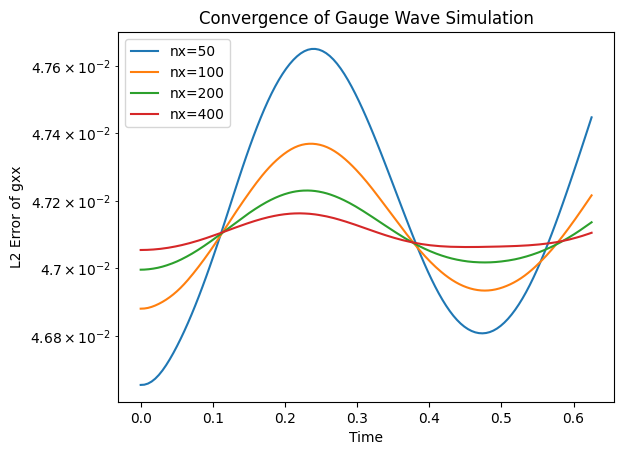

In [7]:
convergence_error = []


for i in range(len(all_gxx)):
    error = jnp.asarray( jnp.asarray(all_gxx[i]) - jnp.asarray(all_gxx_analytic[i]) )
    l2_error = jnp.sqrt( dxs[i] * jnp.sum( error**2, axis=1 ) )
    convergence_error.append(l2_error[-1])  # store final error for convergence plot
    plt.plot(jnp.linspace(0, Nts[i]*dts[i], Nts[i]//plot_freq), l2_error, label=f'nx={nxs[i]}')
    # plot error over time for each resolution
plt.yscale('log')
plt.xlabel('Time')
plt.ylabel('L2 Error of gxx')
plt.title('Convergence of Gauge Wave Simulation')
plt.legend()
plt.show()


Estimated convergence order: 0.0033810758031904697


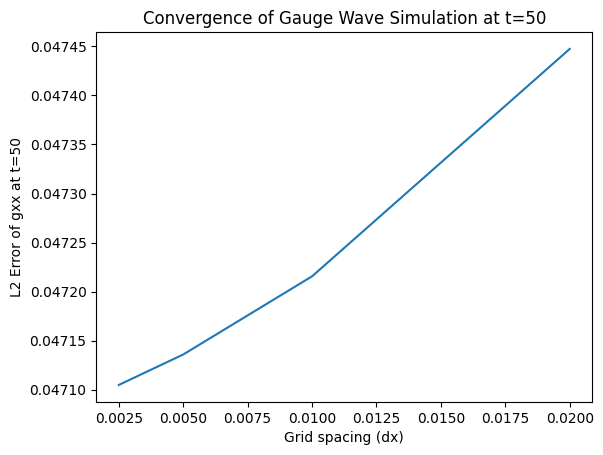

In [8]:
res = stats.linregress( jnp.log(jnp.asarray(dxs)), jnp.log( jnp.asarray(convergence_error) ) ) #+ jnp.log(jnp.asarray(dxs)) )
slope = jnp.abs( res.slope )
print(f"Estimated convergence order: {slope}")

plt.plot(dxs, convergence_error)
# plt.xscale('log')
# plt.yscale('log')
plt.xlabel('Grid spacing (dx)')
plt.ylabel('L2 Error of gxx at t=50')
plt.title('Convergence of Gauge Wave Simulation at t=50')
plt.show()

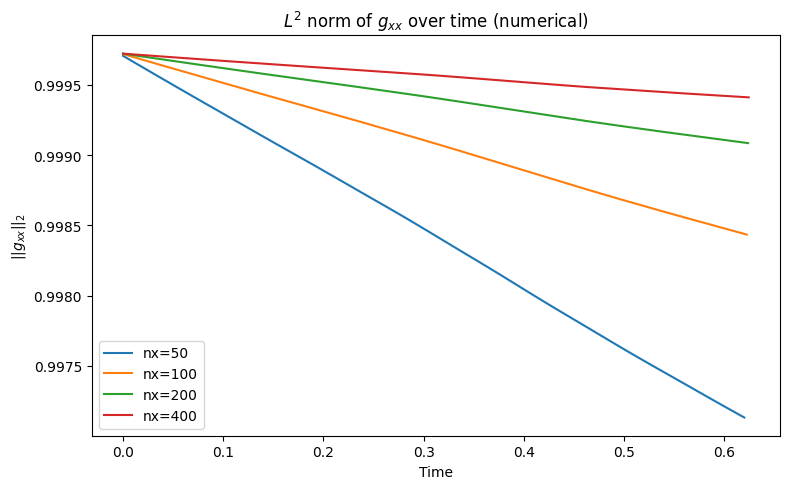

In [9]:
# Plot L2 norm of gxx (numerical) over time for each resolution
plt.figure(figsize=(8, 5))

for i, nx in enumerate(nxs):
    gxx_snap = jnp.asarray(all_gxx[i])  # (n_snaps, nx)
    t_snap = jnp.arange(gxx_snap.shape[0]) * plot_freq * dts[i]

    # Discrete L2 norm over x, dx-weighted
    gxx_l2 = jnp.sqrt(jnp.sum(gxx_snap**2, axis=1) * dxs[i])

    plt.plot(t_snap, gxx_l2, label=f"nx={nx}")

plt.xlabel("Time")
plt.ylabel(r"$||g_{xx}||_{2}$")
plt.title(r"$L^2$ norm of $g_{xx}$ over time (numerical)")
plt.legend()
plt.tight_layout()
plt.show()

Self Consistence Convergence Test: this is a method to verify a numerical simulation by comparing the results at different resolutions to check for convergence towards the exact solution as the grid is refined.

<!-- $$

2^{2k} ( u_{h/k} - u_{h/2k} ) -> \frac{3}{4} h^{2} C
$$ -->

$$

R = \frac{ || u_h ||_2 - || u_{h/2} ||_2 }{ || u_{h/2} ||_2 - || u_{h/4} ||_2 } \approx 2^{p}

In [13]:
norms = []
for i in range(len(all_gxx)):
    gxx_ = jnp.asarray(all_gxx[i])
    dx   = dxs[i]
    # get the numerical solution and the resolution

    norm_2 = jnp.sqrt( dx * jnp.sum(gxx_**2) )
    # calculate the discrete 2 norm of the g_xx at this resolution
    norms.append(norm_2)
    
R = ( norms[0] - norms[1] ) / ( norms[2] - norms[3] )
print(norms)
print(R)
p = jnp.log( jnp.abs(R - 2) )
# compute the numerical convergence rate

print(f"Numerically Calculated Convergence Rate: {p}, Expected: 2")



[Array(11.162697, dtype=float32), Array(15.796783, dtype=float32), Array(22.347301, dtype=float32), Array(31.608994, dtype=float32)]
0.5003499
Numerically Calculated Convergence Rate: 0.4052318334579468, Expected: 2
